In [23]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [24]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")
print("Path to dataset files:", path)

# Find the CSV file inside the downloaded folder
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Found CSV files:", csv_files)

# Load the CSV into a dataframe
df = pd.read_csv(os.path.join(path, csv_files[0]))

# Basic info
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
print(df.dtypes)

Using Colab cache for faster access to the 'house-price-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/house-price-prediction-dataset
Found CSV files: ['House Price Prediction Dataset.csv']
Dataset shape: (2000, 10)
Columns: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int6

In [25]:
# Auto-detect the target column (the column we want to predict)
target_col = None
for col in df.columns:
    if 'price' in col.lower():
        target_col = col
        break

print("Target column:", target_col)
print(df[target_col].describe())

Target column: Price
count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64


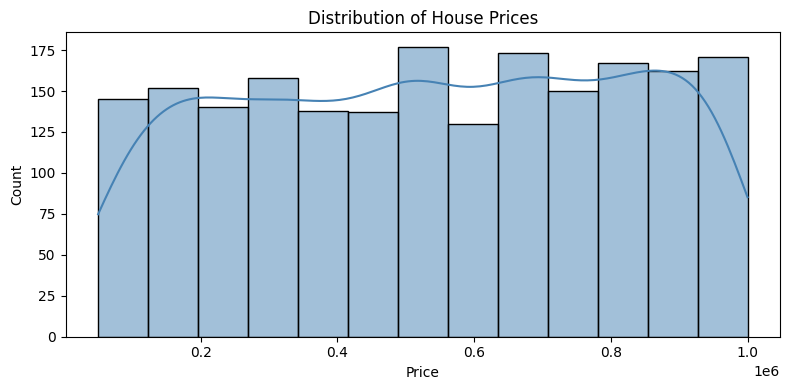

In [26]:
# Plot 1: Distribution of House Prices
plt.figure(figsize=(8, 4))
sns.histplot(df[target_col], kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

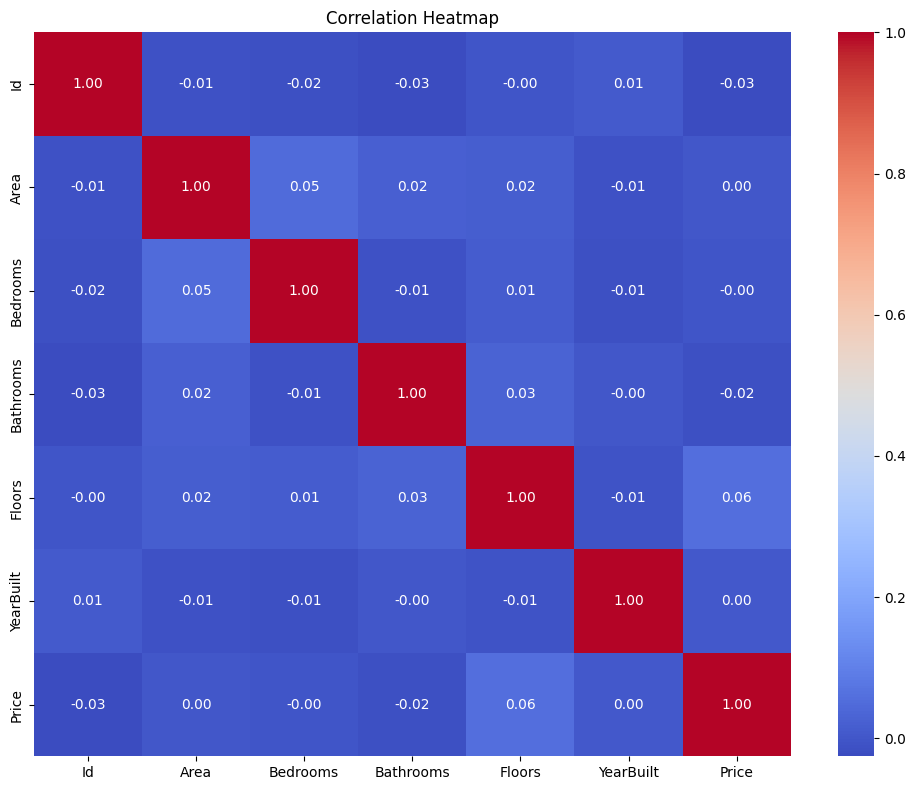

In [27]:
# Plot 2: Correlation Heatmap (how features relate to each other)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

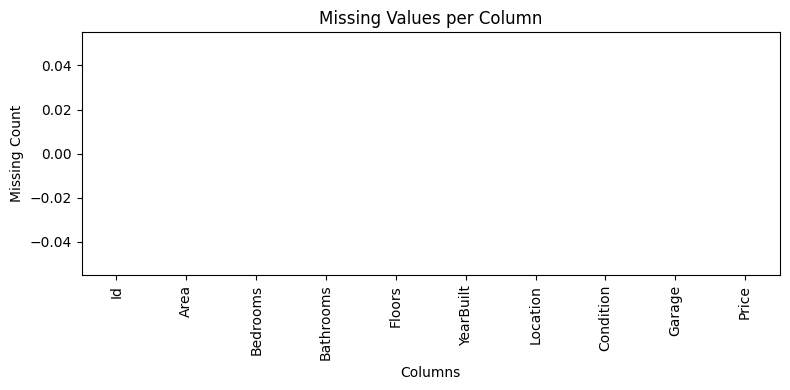

Total missing values: 0


In [28]:
# Plot 3: Check missing values in each column
plt.figure(figsize=(8, 4))
df.isnull().sum().plot(kind='bar', color='tomato')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.tight_layout()
plt.show()

print("Total missing values:", df.isnull().sum().sum())

In [29]:
# Drop ID columns if present (they are useless for prediction)
id_cols = [c for c in df.columns if c.lower() in ['id', 'index']]
df.drop(columns=id_cols, inplace=True, errors='ignore')
print("Dropped columns:", id_cols)


Dropped columns: ['Id']


In [30]:
# Separate features (X) and target (y)
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 8)
Target shape: (2000,)


In [31]:
# Encode categorical (text) columns into numbers
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns found:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding done.")
print(X.head())

Categorical columns found: ['Location', 'Condition', 'Garage']
Encoding done.
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  Garage
0  1360         5          4       3       1970         0          0       0
1  4272         5          4       3       1958         0          0       0
2  3592         2          2       3       1938         0          2       0
3   966         4          2       2       1902         2          1       1
4  4926         1          4       2       1975         0          1       1


In [32]:
# Fill missing values with median of each column
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print("Missing values after filling:", X.isnull().sum().sum())

Missing values after filling: 0


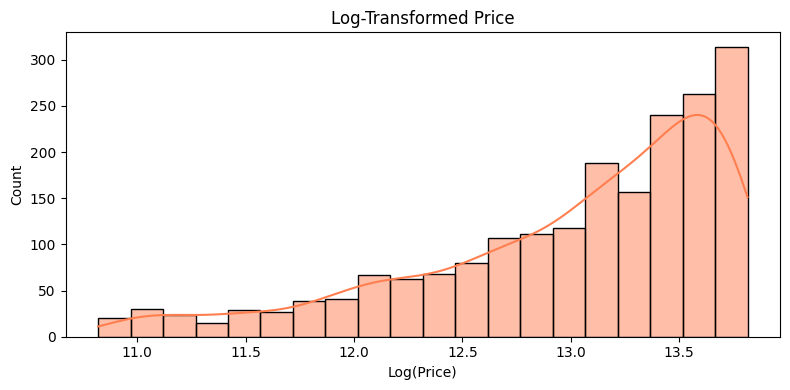

Before log - Mean: 537676.86 | Skew: -0.06
After log  - Mean: 13.0 | Skew: -1.08


In [33]:
# Log-transform the target to reduce skew
y_log = np.log1p(y)

plt.figure(figsize=(8, 4))
sns.histplot(y_log, kde=True, color="coral")
plt.title("Log-Transformed Price")
plt.xlabel("Log(Price)")
plt.tight_layout()
plt.show()

print("Before log - Mean:", round(y.mean(), 2), "| Skew:", round(y.skew(), 2))
print("After log  - Mean:", round(y_log.mean(), 2), "| Skew:", round(y_log.skew(), 2))

In [34]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 1600
Test size : 400


In [35]:
# Scale features so all values are on the same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Scaling done.
X_train_scaled shape: (1600, 8)
X_test_scaled shape : (400, 8)


In [36]:
# Define all models to train
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Lasso Regression":  Lasso(alpha=0.001),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.1,
                                      random_state=42, verbosity=0),
}

In [37]:
# Train each model and evaluate it
results        = {}
trained_models = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on test data
    y_pred = model.predict(X_test_scaled)

    # Convert log predictions back to real prices
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)

    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae  = mean_absolute_error(y_test_actual, y_pred_actual)
    r2   = r2_score(y_test_actual, y_pred_actual)

    # Store results
    results[name]        = {"RMSE": rmse, "MAE": mae, "R2": r2}
    trained_models[name] = model

    print(f"{name}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  R2   : {r2:.4f}")
    print()

Linear Regression
  RMSE : 298,963.41
  MAE  : 259,093.70
  R2   : -0.1488

Ridge Regression
  RMSE : 298,961.64
  MAE  : 259,092.82
  R2   : -0.1488

Lasso Regression
  RMSE : 298,841.14
  MAE  : 259,016.72
  R2   : -0.1479

Random Forest
  RMSE : 315,692.19
  MAE  : 271,701.30
  R2   : -0.2810

XGBoost
  RMSE : 319,294.18
  MAE  : 271,986.47
  R2   : -0.3104



In [38]:
# Show all results in a table sorted by R2
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
print("Model Leaderboard:")
print(results_df.round(4))

Model Leaderboard:
                          RMSE          MAE      R2
Lasso Regression   298841.1358  259016.7187 -0.1479
Ridge Regression   298961.6434  259092.8188 -0.1488
Linear Regression  298963.4058  259093.6966 -0.1488
Random Forest      315692.1890  271701.2986 -0.2810
XGBoost            319294.1833  271986.4705 -0.3104


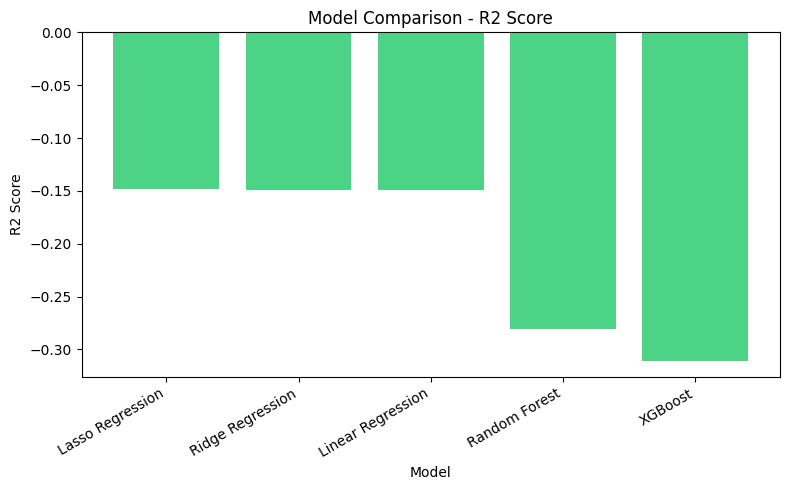

In [39]:
# Plot 1: Compare R2 scores of all models
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["R2"], color="#2ecc71", alpha=0.85)
plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

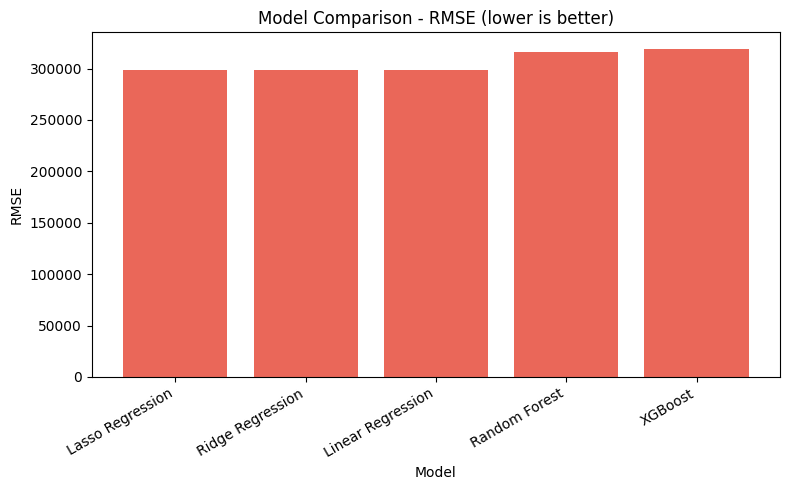

In [40]:
# Plot 2: Compare RMSE of all models
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["RMSE"], color="#e74c3c", alpha=0.85)
plt.title("Model Comparison - RMSE (lower is better)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

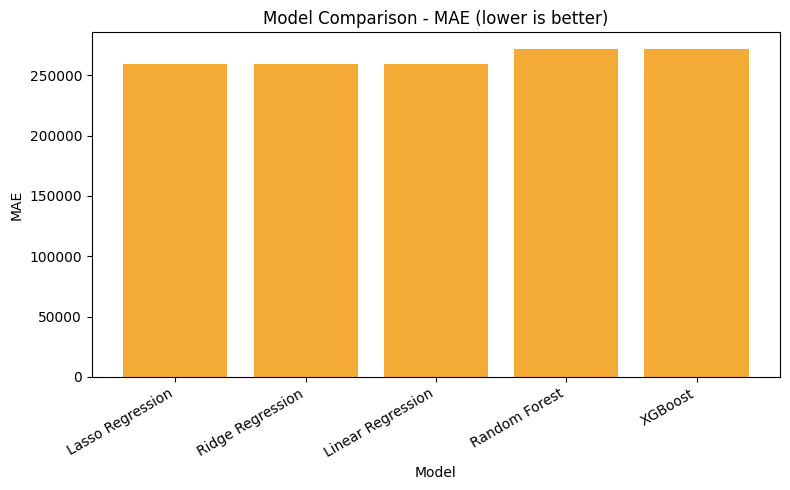

In [41]:
# Plot 3: Compare MAE of all models
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["MAE"], color="#f39c12", alpha=0.85)
plt.title("Model Comparison - MAE (lower is better)")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

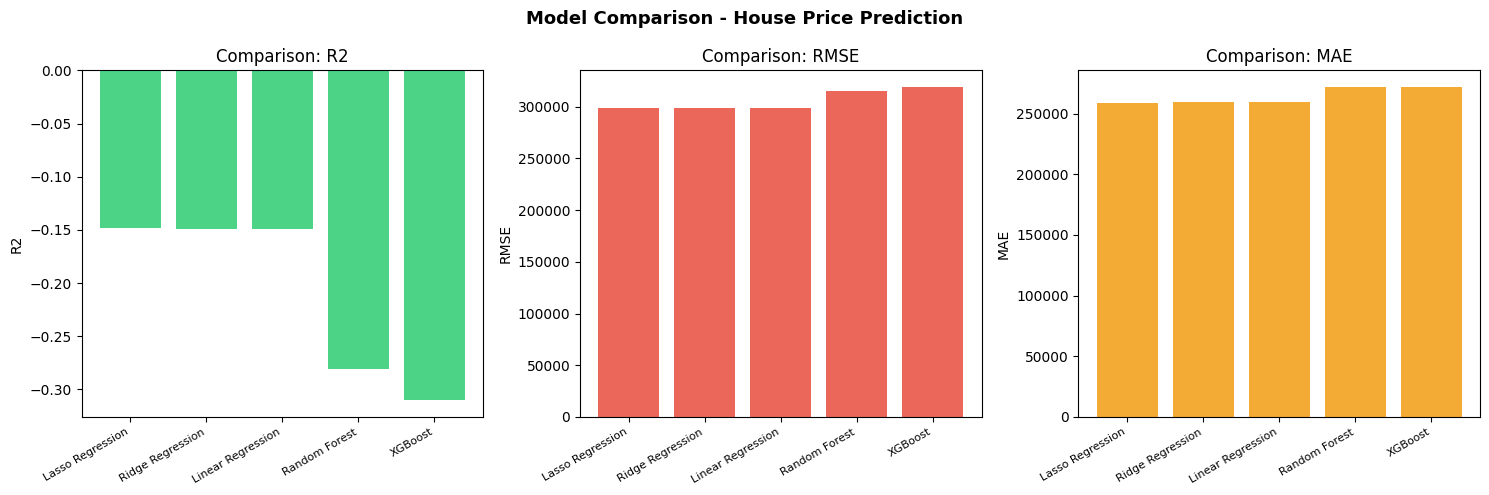

In [43]:
# Plot 4: All 3 metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["R2", "RMSE", "MAE"]
colors  = ["#2ecc71", "#e74c3c", "#f39c12"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(results_df.index, results_df[metric], color=color, alpha=0.85)
    axes[i].set_title("Comparison: " + metric)
    axes[i].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_ylabel(metric)

plt.suptitle("Model Comparison - House Price Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# Print the best model
best_name = results_df.index[0]
print("Best Model :", best_name)
print("R2 Score   :", round(results_df.loc[best_name, "R2"], 4))
print("RMSE       :", round(results_df.loc[best_name, "RMSE"], 2))
print("MAE        :", round(results_df.loc[best_name, "MAE"], 2))

Best Model : Lasso Regression
R2 Score   : -0.1479
RMSE       : 298841.14
MAE        : 259016.72


In [45]:
# Get the best model
best_name  = results_df.index[0]
best_model = trained_models[best_name]

print("Best Model:", best_name)

Best Model: Lasso Regression


In [46]:
# Generate predictions using the best model
y_pred_best   = np.expm1(best_model.predict(X_test_scaled))
y_test_actual = np.expm1(y_test)

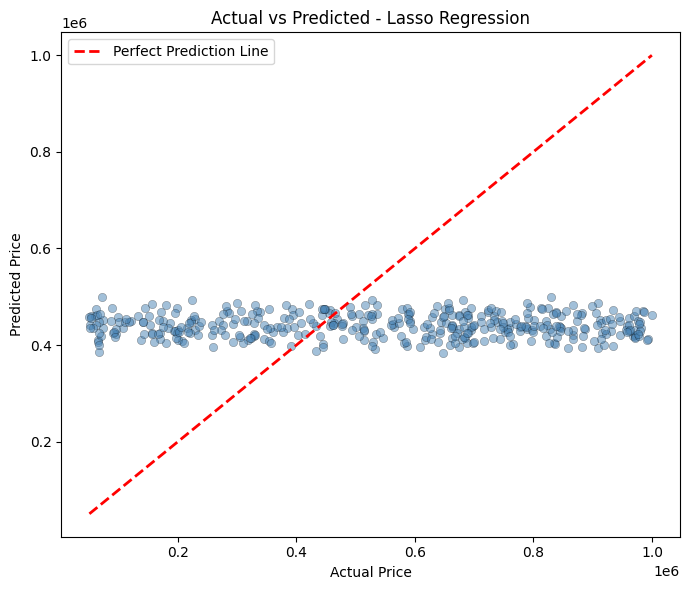

In [47]:
# Plot 1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test_actual, y_pred_best, alpha=0.5,
            color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted - " + best_name)
plt.legend()
plt.tight_layout()
plt.show()

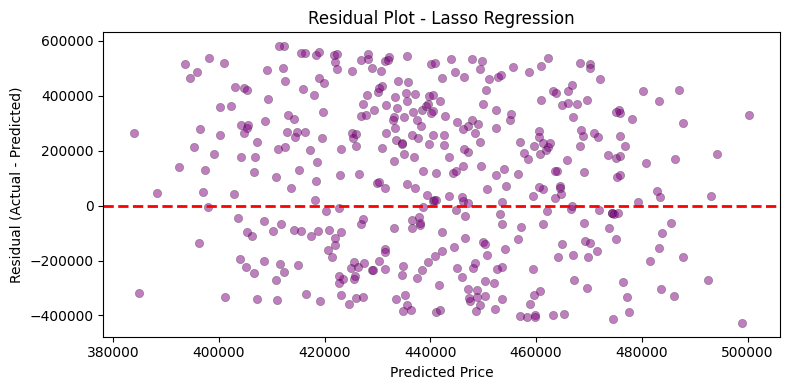

In [48]:
# Plot 2: Residual Plot (difference between actual and predicted)
residuals = y_test_actual - y_pred_best

plt.figure(figsize=(8, 4))
plt.scatter(y_pred_best, residuals, alpha=0.5, color='purple', edgecolors='k', linewidths=0.3)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - " + best_name)
plt.tight_layout()
plt.show()

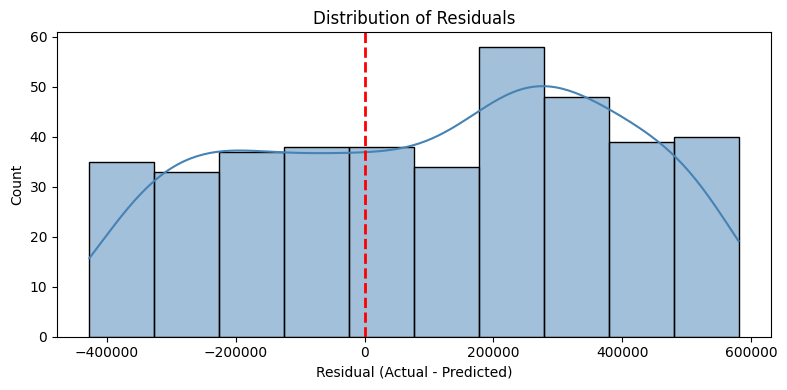

Residual Mean  : 102809.11
Residual Std   : 280951.32


In [49]:
# Plot 3: Distribution of Residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color="steelblue")
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Residual Mean  :", round(residuals.mean(), 2))
print("Residual Std   :", round(residuals.std(), 2))

In [50]:
# Show a sample of actual vs predicted values
comparison_df = pd.DataFrame({
    "Actual Price":    y_test_actual.values,
    "Predicted Price": y_pred_best,
    "Difference":      (y_test_actual.values - y_pred_best)
}).reset_index(drop=True)

print("Sample Predictions:")
print(comparison_df.head(10))

Sample Predictions:
   Actual Price  Predicted Price     Difference
0      514764.0    410770.589606  103993.410394
1      694256.0    431642.067908  262613.932092
2       66375.0    411066.180780 -344691.180780
3      650243.0    475189.886971  175053.113029
4      223285.0    492577.838778 -269292.838778
5      468127.0    453504.905391   14622.094609
6      513002.0    450791.951891   62210.048109
7      911525.0    451151.014979  460373.985021
8      723265.0    468884.867920  254380.132080
9      339416.0    469268.814782 -129852.814782


In [51]:
# Get feature importance from Random Forest
rf = trained_models["Random Forest"]

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Rankings:")
print(importance_df)

Feature Importance Rankings:
     Feature  Importance
0       Area    0.335804
1  YearBuilt    0.269345
2   Bedrooms    0.091714
3  Condition    0.079737
4   Location    0.077691
5  Bathrooms    0.066440
6     Floors    0.046717
7     Garage    0.032552


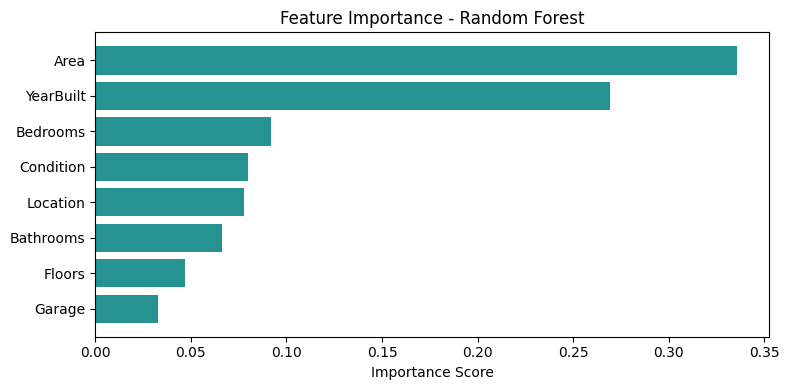

In [52]:
# Plot 1: Horizontal Bar Chart of Feature Importance
plt.figure(figsize=(8, max(4, len(X.columns) * 0.4)))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color='teal', alpha=0.85)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

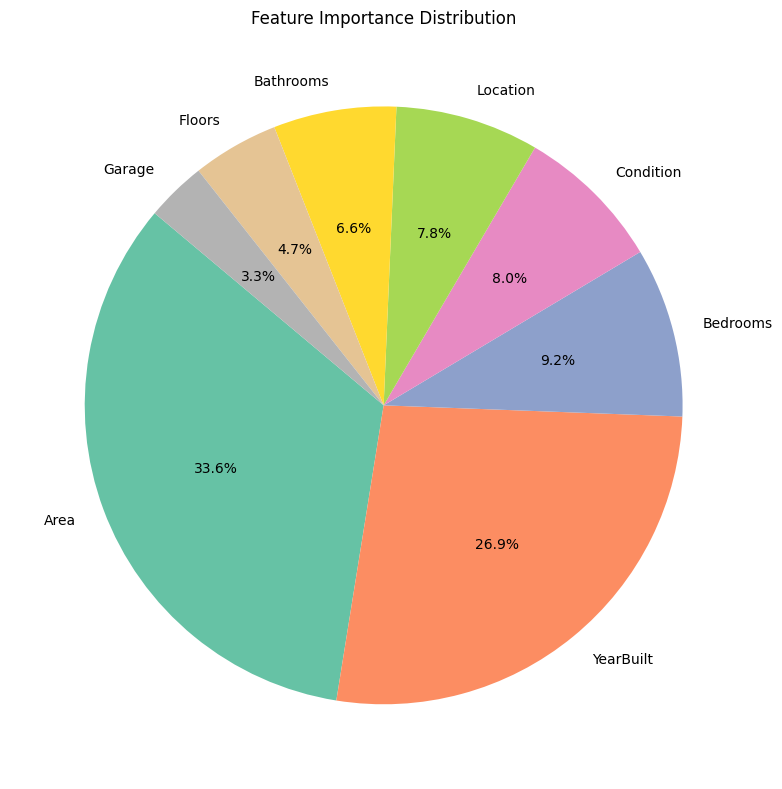

In [53]:
# Plot 2: Feature Importance as Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(importance_df['Importance'],
        labels=importance_df['Feature'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("Set2", len(importance_df)))
plt.title("Feature Importance Distribution")
plt.tight_layout()
plt.show()

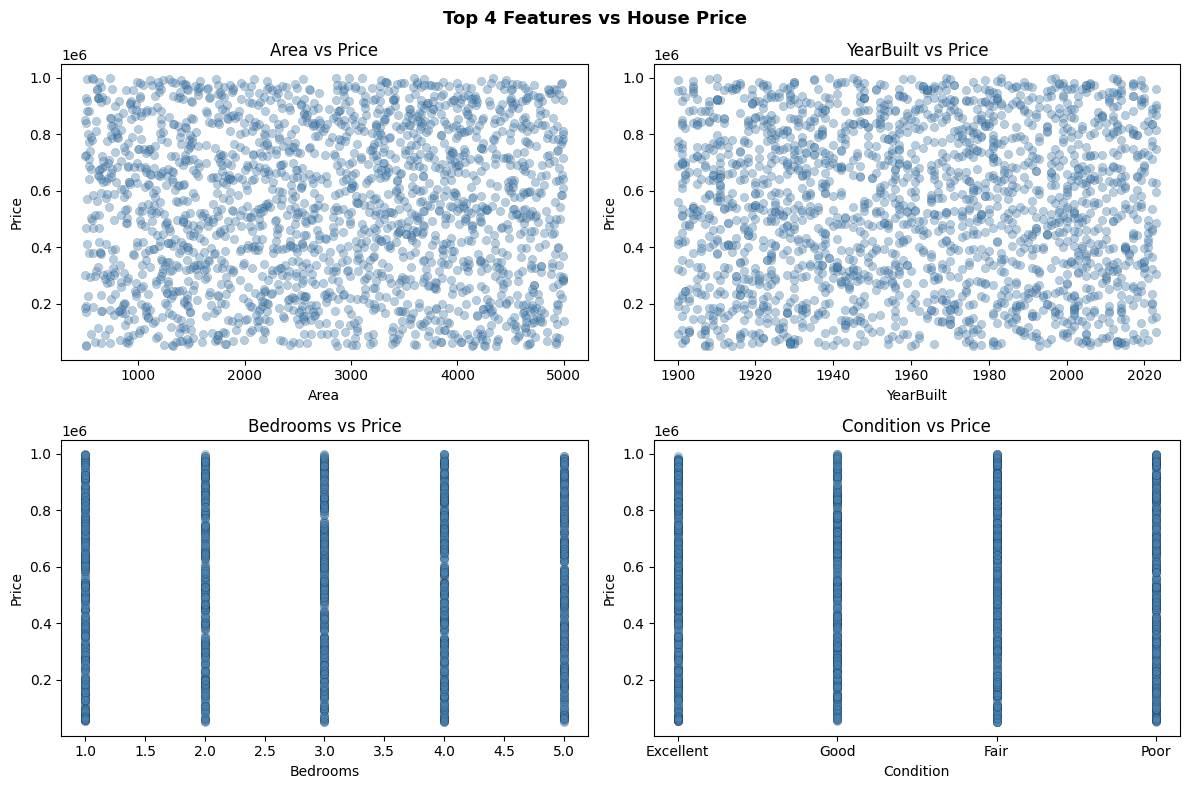

In [54]:
# Plot 3: Top features vs Price (scatter plots)
top_features = importance_df['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df[target_col],
                    alpha=0.4, color='steelblue',
                    edgecolors='k', linewidths=0.2)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")
    axes[i].set_title(feature + " vs Price")

plt.suptitle("Top 4 Features vs House Price", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# Print top 3 most important features
print("Top 3 Most Important Features:")
for i, row in importance_df.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']} - Importance: {row['Importance']:.4f}")

Top 3 Most Important Features:
  1. Area - Importance: 0.3358
  2. YearBuilt - Importance: 0.2693
  3. Bedrooms - Importance: 0.0917


In [56]:
# Check what features the model was trained on
print("Features used for training:")
print(X.columns.tolist())

Features used for training:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']


In [57]:
# Check unique values of categorical columns
# so you can enter valid values below
for col in cat_cols:
    print(f"{col} unique values:", df[col].unique())

Location unique values: ['Downtown' 'Suburban' 'Urban' 'Rural']
Condition unique values: ['Excellent' 'Good' 'Fair' 'Poor']
Garage unique values: ['No' 'Yes']


In [58]:
# Create a new house with your own values
# Change the values below based on your dataset columns

new_house = pd.DataFrame([{
    'Area':           1800,      # size of the house in sq ft
    'Bedrooms':       3,         # number of bedrooms
    'Bathrooms':      2,         # number of bathrooms
    'Floors':         2,         # number of floors
    'YearBuilt':      2010,      # year the house was built
    'Garage':         1,         # 1 = has garage, 0 = no garage
    'Location':       'Urban',   # change to a valid value from above
    'Condition':      'Good',    # change to a valid value from above
}])

print("New house details:")
print(new_house)

New house details:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Garage Location Condition
0  1800         3          2       2       2010       1    Urban      Good


In [59]:
# Encode categorical columns in new house
# using the same label encoder logic
for col in cat_cols:
    if col in new_house.columns:
        new_house[col] = le.fit_transform(new_house[col].astype(str))

print("After encoding:")
print(new_house)

After encoding:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Garage  Location  Condition
0  1800         3          2       2       2010       0         0          0


In [60]:
# Make sure columns are in the same order as training data
new_house = new_house.reindex(columns=X.columns, fill_value=0)

# Scale the new house data
new_house_scaled = scaler.transform(new_house)

print("New house scaled successfully.")

New house scaled successfully.


In [61]:
# Predict the price
predicted_log_price = best_model.predict(new_house_scaled)
predicted_price     = np.expm1(predicted_log_price)[0]

print("---------------------------")
print("Predicted House Price:", f"{predicted_price:,.2f}")
print("---------------------------")

---------------------------
Predicted House Price: 464,695.62
---------------------------


In [62]:
# Compare with dataset price range
print("Price range in dataset:")
print("  Minimum Price :", f"{df[target_col].min():,.2f}")
print("  Maximum Price :", f"{df[target_col].max():,.2f}")
print("  Average Price :", f"{df[target_col].mean():,.2f}")
print("  Your Prediction:", f"{predicted_price:,.2f}")

Price range in dataset:
  Minimum Price : 50,005.00
  Maximum Price : 999,656.00
  Average Price : 537,676.85
  Your Prediction: 464,695.62


In [64]:
multiple_houses = pd.DataFrame([
    {'Area': 1200, 'Bedrooms': 2, 'Bathrooms': 1, 'Floors': 1,
     'YearBuilt': 2000, 'Garage': 0, 'Location': 'Rural',  'Condition': 'Fair'},
    {'Area': 2000, 'Bedrooms': 4, 'Bathrooms': 3, 'Floors': 2,
     'YearBuilt': 2015, 'Garage': 1, 'Location': 'Urban',  'Condition': 'Good'},
    {'Area': 3500, 'Bedrooms': 5, 'Bathrooms': 4, 'Floors': 3,
     'YearBuilt': 2020, 'Garage': 1, 'Location': 'Suburb', 'Condition': 'Excellent'},
])

for col in cat_cols:
    if col in multiple_houses.columns:
        multiple_houses[col] = le.fit_transform(multiple_houses[col].astype(str))

multiple_houses = multiple_houses.reindex(columns=X.columns, fill_value=0)
multiple_scaled = scaler.transform(multiple_houses)

predictions = np.expm1(best_model.predict(multiple_scaled))

print("Predictions for Multiple Houses:")
for i, price in enumerate(predictions):
    print(f"House {i+1} predicted price: {price:,.2f}")

Predictions for Multiple Houses:
House 1 predicted price: 444,889.47
House 2 predicted price: 447,723.49
House 3 predicted price: 473,758.86


In [65]:
from google.colab import widgets

In [66]:
from ipywidgets import interact, IntSlider, Dropdown

In [67]:
@interact(
    Area       = IntSlider(min=500,  max=5000, step=100, value=1800),
    Bedrooms   = IntSlider(min=1,    max=10,   step=1,   value=3),
    Bathrooms  = IntSlider(min=1,    max=8,    step=1,   value=2),
    Floors     = IntSlider(min=1,    max=5,    step=1,   value=2),
    YearBuilt  = IntSlider(min=1900, max=2024, step=1,   value=2010),
    Garage     = Dropdown(options=[('Yes', 1), ('No', 0)]),
    Location   = Dropdown(options=['Urban', 'Rural', 'Suburb']),
    Condition  = Dropdown(options=['Excellent', 'Good', 'Fair', 'Poor'])
)

def predict_price(Area, Bedrooms, Bathrooms, Floors,
                  YearBuilt, Garage, Location, Condition):

    # Build input
    new_house = pd.DataFrame([{
        'Area':      Area,
        'Bedrooms':  Bedrooms,
        'Bathrooms': Bathrooms,
        'Floors':    Floors,
        'YearBuilt': YearBuilt,
        'Garage':    Garage,
        'Location':  Location,
        'Condition': Condition,
    }])

    # Encode categorical columns
    for col in cat_cols:
        if col in new_house.columns:
            new_house[col] = le.fit_transform(new_house[col].astype(str))

    # Reindex and scale
    new_house        = new_house.reindex(columns=X.columns, fill_value=0)
    new_house_scaled = scaler.transform(new_house)

    # Predict
    predicted_price = np.expm1(best_model.predict(new_house_scaled))[0]

    # Show result
    print("----------------------------------")
    print("House Details:")
    print("  Area      :", Area, "sqft")
    print("  Bedrooms  :", Bedrooms)
    print("  Bathrooms :", Bathrooms)
    print("  Floors    :", Floors)
    print("  Year Built:", YearBuilt)
    print("  Garage    :", "Yes" if Garage == 1 else "No")
    print("  Location  :", Location)
    print("  Condition :", Condition)
    print("----------------------------------")
    print(f"Predicted Price  : {predicted_price:,.2f}")
    print(f"Dataset Average  : {df[target_col].mean():,.2f}")
    print(f"Dataset Minimum  : {df[target_col].min():,.2f}")
    print(f"Dataset Maximum  : {df[target_col].max():,.2f}")
    print("----------------------------------")

    if predicted_price > df[target_col].mean():
        print("This house is ABOVE average price.")
    else:
        print("This house is BELOW average price.")

interactive(children=(IntSlider(value=1800, description='Area', max=5000, min=500, step=100), IntSlider(value=…

In [76]:
!pip install streamlit pyngrok -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [77]:
app_code = '''
import streamlit as st
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="House Price Predictor", layout="centered")

@st.cache_resource
def load_and_train():
    path       = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")
    csv_files  = [f for f in os.listdir(path) if f.endswith(".csv")]
    df         = pd.read_csv(os.path.join(path, csv_files[0]))
    target_col = None
    for col in df.columns:
        if "price" in col.lower():
            target_col = col
            break
    id_cols = [c for c in df.columns if c.lower() in ["id", "index"]]
    df.drop(columns=id_cols, inplace=True, errors="ignore")
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        X[col] = le.fit_transform(X[col].astype(str))
    X.fillna(X.median(), inplace=True)
    y.fillna(y.median(), inplace=True)
    y_log = np.log1p(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=42)
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    best_model     = RandomForestRegressor(n_estimators=100, random_state=42)
    best_model.fit(X_train_scaled, y_train)
    return df, X, y, target_col, cat_cols, le, scaler, best_model

df, X, y, target_col, cat_cols, le, scaler, best_model = load_and_train()

st.title("House Price Predictor")
st.markdown("Adjust the values below and click Predict to get the house price.")
st.markdown("---")

col1, col2 = st.columns(2)

with col1:
    Area      = st.slider("Area (sqft)",  500,  5000, 1800, 100)
    Bedrooms  = st.slider("Bedrooms",     1,    10,   3,    1)
    Bathrooms = st.slider("Bathrooms",    1,    8,    2,    1)
    Floors    = st.slider("Floors",       1,    5,    2,    1)

with col2:
    YearBuilt = st.slider("Year Built",   1900, 2024, 2010, 1)
    Garage    = st.selectbox("Garage",    ["Yes", "No"])
    Location  = st.selectbox("Location",  ["Urban", "Rural", "Suburb"])
    Condition = st.selectbox("Condition", ["Excellent", "Good", "Fair", "Poor"])

st.markdown("---")

if st.button("Predict Price", use_container_width=True):

    garage_val = 1 if Garage == "Yes" else 0

    new_house = pd.DataFrame([{
        "Area":      Area,
        "Bedrooms":  Bedrooms,
        "Bathrooms": Bathrooms,
        "Floors":    Floors,
        "YearBuilt": YearBuilt,
        "Garage":    garage_val,
        "Location":  Location,
        "Condition": Condition,
    }])

    for col in cat_cols:
        if col in new_house.columns:
            new_house[col] = le.fit_transform(new_house[col].astype(str))

    new_house        = new_house.reindex(columns=X.columns, fill_value=0)
    new_house_scaled = scaler.transform(new_house)
    predicted_price  = np.expm1(best_model.predict(new_house_scaled))[0]
    avg_price        = df[target_col].mean()

    st.markdown("---")
    st.subheader("House Details")

    c1, c2 = st.columns(2)
    c1.write(f"Area       : {Area} sqft")
    c1.write(f"Bedrooms   : {Bedrooms}")
    c1.write(f"Bathrooms  : {Bathrooms}")
    c1.write(f"Floors     : {Floors}")
    c2.write(f"Year Built : {YearBuilt}")
    c2.write(f"Garage     : {Garage}")
    c2.write(f"Location   : {Location}")
    c2.write(f"Condition  : {Condition}")

    st.markdown("---")

    st.metric(label="Predicted Price",  value=f"${predicted_price:,.2f}")
    st.metric(label="Dataset Average",  value=f"${avg_price:,.2f}")
    st.metric(label="Dataset Minimum",  value=f"${df[target_col].min():,.2f}")
    st.metric(label="Dataset Maximum",  value=f"${df[target_col].max():,.2f}")

    st.markdown("---")

    if predicted_price > avg_price:
        st.success("This house is ABOVE average price.")
    else:
        st.info("This house is BELOW average price.")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py saved.")

app.py saved.


In [80]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
print("cloudflared installed.")

cloudflared installed.


In [81]:
app_code = '''
import streamlit as st
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="House Price Predictor", layout="centered")

@st.cache_resource
def load_and_train():
    path       = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")
    csv_files  = [f for f in os.listdir(path) if f.endswith(".csv")]
    df         = pd.read_csv(os.path.join(path, csv_files[0]))
    target_col = None
    for col in df.columns:
        if "price" in col.lower():
            target_col = col
            break
    id_cols = [c for c in df.columns if c.lower() in ["id", "index"]]
    df.drop(columns=id_cols, inplace=True, errors="ignore")
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        X[col] = le.fit_transform(X[col].astype(str))
    X.fillna(X.median(), inplace=True)
    y.fillna(y.median(), inplace=True)
    y_log = np.log1p(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=42)
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    best_model     = RandomForestRegressor(n_estimators=100, random_state=42)
    best_model.fit(X_train_scaled, y_train)
    return df, X, y, target_col, cat_cols, le, scaler, best_model

df, X, y, target_col, cat_cols, le, scaler, best_model = load_and_train()

st.title("House Price Predictor")
st.markdown("Adjust the values below and click Predict to get the house price.")
st.markdown("---")

col1, col2 = st.columns(2)

with col1:
    Area      = st.slider("Area (sqft)",  500,  5000, 1800, 100)
    Bedrooms  = st.slider("Bedrooms",     1,    10,   3,    1)
    Bathrooms = st.slider("Bathrooms",    1,    8,    2,    1)
    Floors    = st.slider("Floors",       1,    5,    2,    1)

with col2:
    YearBuilt = st.slider("Year Built",   1900, 2024, 2010, 1)
    Garage    = st.selectbox("Garage",    ["Yes", "No"])
    Location  = st.selectbox("Location",  ["Urban", "Rural", "Suburb"])
    Condition = st.selectbox("Condition", ["Excellent", "Good", "Fair", "Poor"])

st.markdown("---")

if st.button("Predict Price", use_container_width=True):
    garage_val = 1 if Garage == "Yes" else 0
    new_house = pd.DataFrame([{
        "Area": Area, "Bedrooms": Bedrooms, "Bathrooms": Bathrooms,
        "Floors": Floors, "YearBuilt": YearBuilt, "Garage": garage_val,
        "Location": Location, "Condition": Condition,
    }])
    for col in cat_cols:
        if col in new_house.columns:
            new_house[col] = le.fit_transform(new_house[col].astype(str))
    new_house        = new_house.reindex(columns=X.columns, fill_value=0)
    new_house_scaled = scaler.transform(new_house)
    predicted_price  = np.expm1(best_model.predict(new_house_scaled))[0]
    avg_price        = df[target_col].mean()

    st.markdown("---")
    st.subheader("House Details")
    c1, c2 = st.columns(2)
    c1.write(f"Area       : {Area} sqft")
    c1.write(f"Bedrooms   : {Bedrooms}")
    c1.write(f"Bathrooms  : {Bathrooms}")
    c1.write(f"Floors     : {Floors}")
    c2.write(f"Year Built : {YearBuilt}")
    c2.write(f"Garage     : {Garage}")
    c2.write(f"Location   : {Location}")
    c2.write(f"Condition  : {Condition}")
    st.markdown("---")
    st.metric(label="Predicted Price", value=f"${predicted_price:,.2f}")
    st.metric(label="Dataset Average", value=f"${avg_price:,.2f}")
    st.metric(label="Dataset Minimum", value=f"${df[target_col].min():,.2f}")
    st.metric(label="Dataset Maximum", value=f"${df[target_col].max():,.2f}")
    st.markdown("---")
    if predicted_price > avg_price:
        st.success("This house is ABOVE average price.")
    else:
        st.info("This house is BELOW average price.")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py saved.")

app.py saved.


In [82]:
import subprocess
import time
import re

# Start streamlit
subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.port", "8501",
                  "--server.headless", "true"])

time.sleep(5)

# Start cloudflared tunnel
cf = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Extract the public URL from output
print("Getting URL... please wait 10 seconds")
time.sleep(10)

for line in cf.stderr:
    line = line.decode("utf8")
    if "trycloudflare.com" in line:
        url = re.search(r'https://[^\s]+trycloudflare\.com', line)
        if url:
            print("Open this URL directly:", url.group())
            break

Getting URL... please wait 10 seconds
Open this URL directly: https://overall-determining-screenshot-store.trycloudflare.com
